# Teoremas Limites

<hr>

https://www.youtube.com/watch?v=zeJD6dqJ5lo 
"But what is the Central Limit Theorem?"
3Blue1Brown 

https://www.youtube.com/watch?v=YAlJCEDH2uY "The Central Limit Theorem, Clearly Explained!" StatsQuest

Vamos inicialmente gerar diversas amostras de tamanho $n$ a partir de uma distribuição normal e criar um histograma das médias amostrais calculadas.

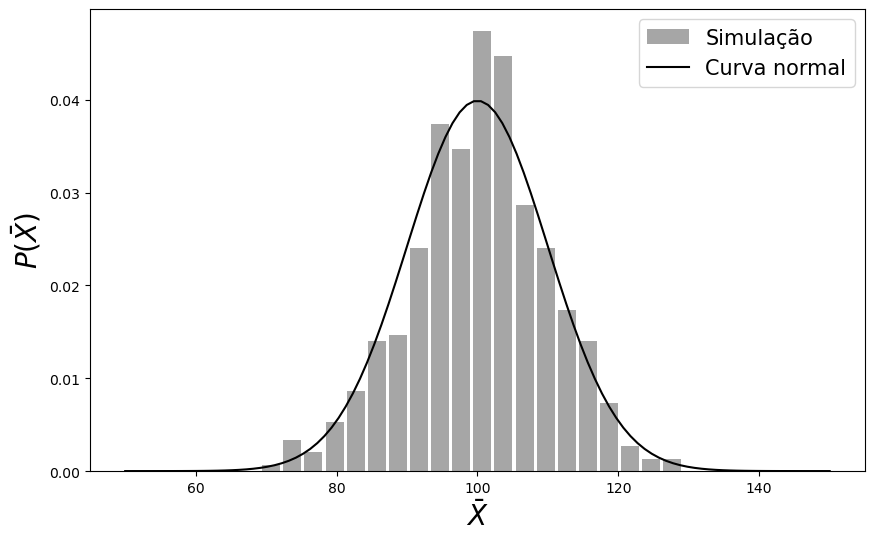

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
np.random.seed(42)

sample_means = [] # armazena a média amostral
# parâmetros da distribuição normal
mu = 100; std = 10
s = 100 # número de amostras
n = 500 # tamanho de cada amostra
for i in np.arange(0,s):
    # amostras são geradas de uma normal
    X = np.random.normal(mu,std, n)
    # armazena a média amostral
    sample_means.append(np.mean(X))
# mostra os resultados da simulação
plt.figure(figsize=(10,6))
plt.hist(x=X, bins='auto',color='gray',
         alpha=0.7, rwidth=0.85, density = True, label='Simulação')
plt.xlabel(r'$\bar{X}$', fontsize=20)
plt.ylabel(r'$P(\bar{X})$', fontsize=20)

# Mostra a curva teorica
xmin, xmax = min(sample_means), max(sample_means)
lnspc = np.linspace(50, 150, 100)
pdf_g = stats.norm.pdf(lnspc, mu,std)
plt.plot(lnspc, pdf_g, label="Curva normal", color='black')
plt.legend(fontsize = 15)
plt.show(True)

Notamos que a distribuição da média amostral se aproxima de uma distribuição normal. Nessa aula, vamos aprender sobre o Teorema Central do Limite, que formaliza esse resultado.

### Amostras aleatórias

Definição: Uma amostra aleatória simples de tamanho n da variável aleatória X, com uma dada distribuição de probabilidades, é o conjunto de variáveis aleatórias independentes $X_1,X_2, \ldots, X_n$, cada uma com a mesma distribuição de $X$.

Podemos gerar amostras aleatórias a partir de uma população com uma dada distribuição de probabilidade. Vamos supor que a população segue uma distribuição normal com média $\mu$ e desvio padrão $\sigma$. Gerando $n$ amostras de tamanho $m$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mu = 0
sigma = 1
n = 3
m = 4
for i in range(0,n):
    X = np.random.normal(mu, sigma,m)
    print('Amostra', i, ':', X)

Amostra 0 : [ 0.09820615 -0.06410823  0.95179076  1.53283114]
Amostra 1 : [ 0.68684694  1.01154375 -0.21740423  0.12540481]
Amostra 2 : [ 1.48573207  0.52671146 -0.24202988  0.03255055]


Teorema: Seja $X$ uma variável aleatória com esperança $E[X] = \mu$ e variância $V(X) = \sigma^2$. Seja $\bar{X}$ a média amostral de uma amostra de tamanho $n$. Então:
$$
E[\bar{X}]= \mu, \quad V(\bar{X})=\frac{\sigma^2}{n}.
$$

Vamos verificar esse teorema através de simulações:

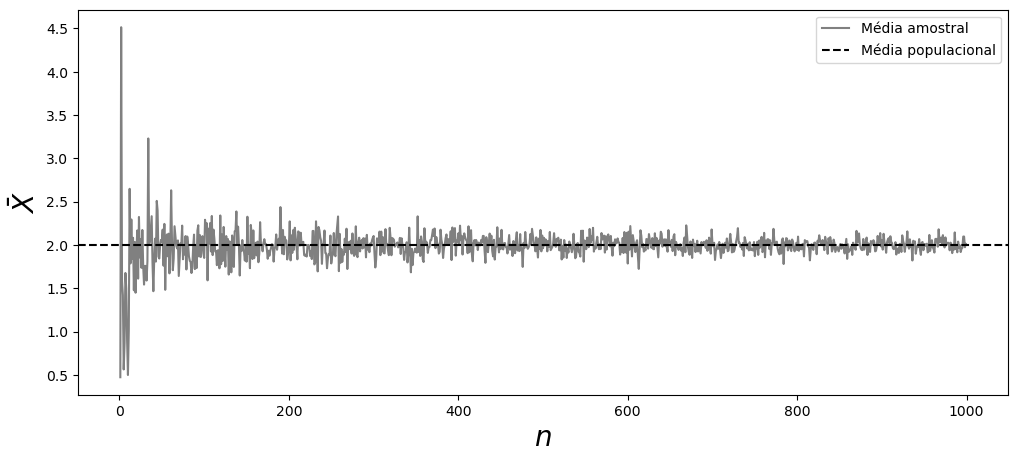

In [ ]:
vn = []
vmean = []
mu = 2
std = 1
for n in np.arange(1,1000):
    #X = np.random.normal(mu,std, n) # X is generated from a normal distribution
    X = np.random.exponential(mu, n) # X is generated from an exponential distribution
    vmean.append(np.mean(X))
    vn.append(n)
plt.figure(figsize=(12,5))
plt.plot(vn, vmean, '-', color='gray', label='Média amostral')
plt.axhline(y=mu, color='k', linestyle='--', label = 'Média populacional')
plt.xlabel(r'$n$', fontsize=20)
plt.ylabel(r'$\bar{X}$', fontsize=20)
plt.legend()
plt.show(True)

Notamos que a média amostral converge para a média populacional $\mu$ quando aumentamos o tamanho da amostra.

---
## Lei dos grandes números

- A Lei dos Grandes Números garante que, com dados suficientes (Big Data), as métricas de desempenho calculadas em amostras de teste sejam estimativas confiáveis do desempenho real do modelo em produção

A acurácia de experimentos estatísticos tende a aumentar com o número de tentativas.

A Lei dos Grandes Números afirma que a média dos resultados obtidos para um grande número de experimentos deve ser aproximar do valor esperado da variável aleatória, isto é,
\begin{equation}
\lim _{n\to \infty }\sum _{i=1}^{n}{\frac {X_{i}}{n}}= \mu = E[X].
\end{equation}

Lei Forte dos Grande Números:
Seja $S_n = \sum_{i=1}^n X_i$ a soma de $n$ variáveis aleatórias independentes e identicamente distribuídas, cada uma com média $E[X_i] = \mu$, $i=1,2,\ldots, n$.  Seja ainda $\bar{X} = S_n/n$. Então,
\begin{equation}
P\left(\lim_{n\rightarrow \infty} \bar{X} = \mu \right) = 1.
\end{equation}

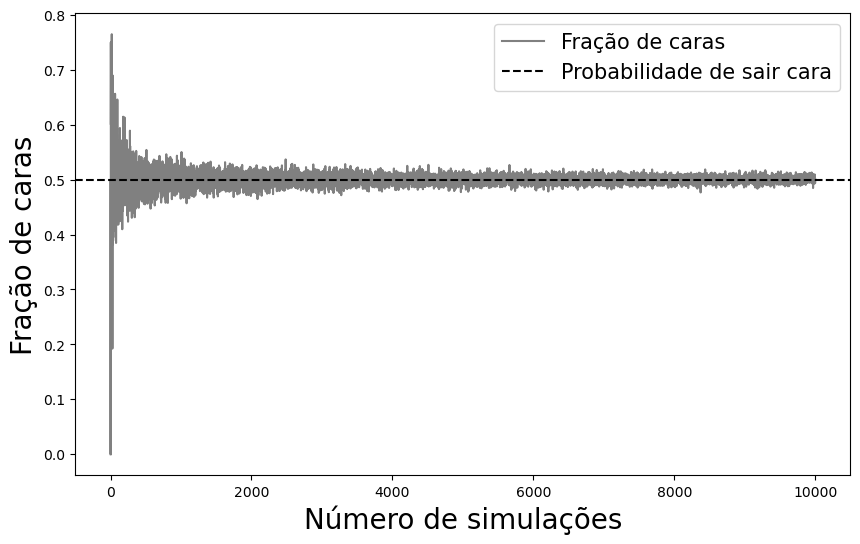

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2011)

p = 0.5 # probabilidade de sair cara
Ns = 10000 # número máximo de simulações
vnh = [] # armazena o número de caras
vsim = [] # armazena o número de simulações
for ns in np.arange(1,Ns+1):
    nh = 0 # número de caras
    # realiza ns lançamentos
    for s in range(0,ns):
        # verifica se sai uma cara
        if(np.random.uniform() < p):
            nh = nh+1
    # armazena a probabilidade calculada
    vnh.append(nh/ns)
    vsim.append(ns)
# mostra os resultados
plt.figure(figsize=(10,6))
plt.plot(vsim, vnh, '-', color='gray',
         label='Fração de caras')
plt.axhline(y=p, color='k', linestyle='--',
            label = 'Probabilidade de sair cara')
plt.xlabel('Número de simulações', fontsize=20)
plt.ylabel('Fração de caras', fontsize=20)
plt.legend(fontsize = 15)
plt.show(True)

---
## Teorema Central do Limite

O Teorema Central do Limite afirma que, independentemente da distribuição original dos dados, a distribuição da **média amostral** tende a uma **Distribuição Normal** conforme o tamanho da amostra cresce.

- *Inferência Populacional: O TCL permite fazer afirmações sobre parâmetros populacionais (como a média) usando amostras, sem precisar conhecer a distribuição exata da população*

Para o TCL valer, precisamos de:

- Variáveis aleatórias independentes e identicamente distribuídas (i.i.d.)
- Média finita $\mu$
- Variância finita $\sigma^2 < \infty$

Distribuição da Média Amostral

Para $n$ grande:

$$
\bar{X} \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)
$$

- $\bar{X}$: média amostral  
- $\mu$: média populacional  
- $\sigma^2$: variância populacional  

Interpretação:  
Mesmo que os dados originais não sejam normais, a média deles será aproximadamente normal para amostras grandes.

Padronização (Z-score)

$$
Z = \frac{\bar{X} - \mu}{\sigma / \sqrt{n}} \sim \mathcal{N}(0,1)
$$

Isso permite usar a normal padrão para calcular probabilidades.

- Dados podem ser não normais  
- Médias de amostras grandes → seguem distribuição normal  

Em Data Science e Machine Learning:
Mais dados → melhor aproximação da distribuição normal → modelos mais estáveis

**Teorema:** Seja uma amostra aleatória $(X_1,X_2,\ldots,X_n)$ retiradas de uma população com média $\mu$ e variância $\sigma$. A distribuição amostral de $\bar{X}$ aproxima-se, para n grande, de uma distribuição normal com média $E[\bar{X}]=\mu$ e variância $\sigma^2/n$.<br>

Vamos verificar esse teorema através de simulações:

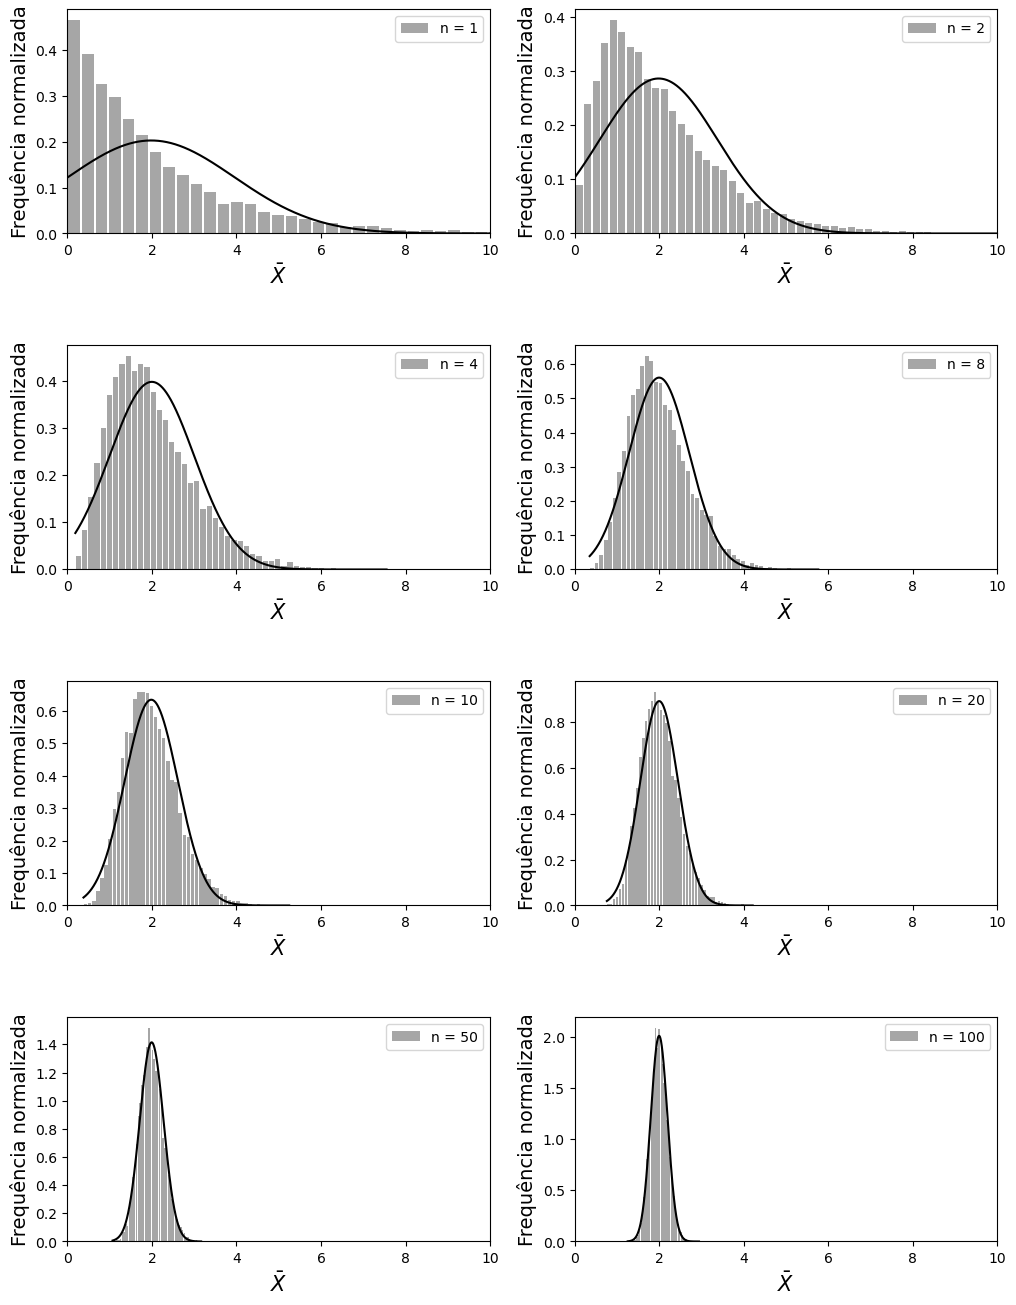

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
import random as random
np.random.seed(42)

# número de elementos em cada amostra
vn =  [1, 2 , 4 , 8, 10, 20, 50, 100]
S = 10000 # número de amostras
mu = 2 # média populacional
# gera a população
pop = np.random.exponential(mu, 20000)
#pop = np.random.uniform(0,2*mu, 20000)

plt.figure(figsize=(12,16))
plt.subplots_adjust(hspace=0.5)
aux = 0 # variavel auxiliar
for n in vn: # varia o tamanho da amostra
    vmean = []
    for s in range(0,S):
        # seleciona s amostras de tamanho n
        X = random.choices(pop,k=n)
        # armazena a média da amostra
        vmean.append(np.mean(X))
    # mostra o histograma
    plt.subplot(4, 2, aux + 1)
    aux = aux + 1
    plt.hist(x=vmean, bins=50, color='gray',
             alpha=0.7, rwidth=0.85, density=True,
             label = 'n = '+str(n))
    plt.xlabel(r'$\bar{X}$', fontsize=15)
    plt.ylabel('Frequência normalizada', fontsize=14)
    plt.legend()
    plt.xlim(0,10)
    # Mostra a curva normal ajustada
    xmin, xmax = min(vmean), max(vmean)
    lnspc = np.linspace(xmin, xmax, len(vmean))
    m, s = stats.norm.fit(vmean) #
    pdf_g = stats.norm.pdf(lnspc, m, s)
    plt.plot(lnspc, pdf_g, label="Normal", color='black')
plt.show(True)

Notamos que a distribuição da média amostral tende à distribuição Normal quando aumentamos o tamanho da amostra. Notem que a média da distribuição converge para a média da população, isto é, $E[\bar{X}]=\mu$.

---

### Exemplos



**Exemplo:** Seja a variável aleatória com distribuição de probabilidade: P(X=3)=0,5; P(X=6)=0,3; P(X=8)=0,2. Uma amostra com 50 observações é sorteada. Qual é a probabilidade de que a média amostral ser maior do que 5?

A média e o desvio padrão dessa população:

In [ ]:
X = [3,6,8]
P = [0.5,0.3,0.2]
x = 5
E = 0
E2 = 0
n = 50
for i in range(0, len(X)):
    E = E + X[i]*P[i]
    E2 = E2 + (X[i]**2)*P[i]
V = E2-E**2
print("Esperança:", E, "Variância:",V)

Esperança: 4.9 Variância: 4.089999999999996


In [ ]:
from IPython.display import display, Math, Latex
import scipy.stats as st

z = (5-E)/(np.sqrt(V/n))
print('z = ', z)
p = 1-st.norm.cdf(z)
display(Math(r'P(\bar{X} <'+str(x) +')=' +str(p)))

z =  0.3496418006375317


<IPython.core.display.Math object>

Vamos sortear várias amostras de tamanho n=50 e verificar qual a probabilidade da média dessa amostra ser maior do que 5.

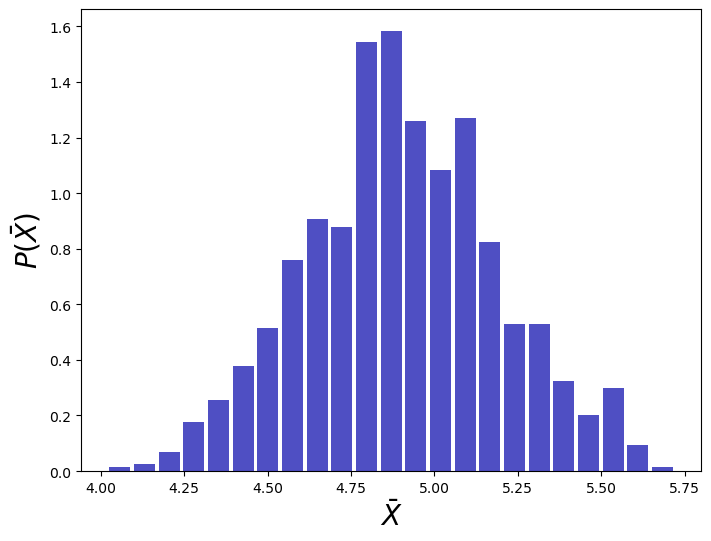

Média das amostras: 4.901320000000001 Média da população: 4.9


In [ ]:
import matplotlib.pyplot as plt

n = 50
ns = 1000 # número de simulações
vx = [] # armazena a média amostral
for s in range(0,ns):
    A = np.random.choice(X, n, p=P)
    vx.append(np.mean(A))
plt.figure(figsize=(8,6))
plt.hist(x=vx, bins='auto',color='#0504aa', alpha=0.7, rwidth=0.85, density = True)
plt.xlabel(r'$\bar{X}$', fontsize=20)
plt.ylabel(r'$P(\bar{X})$', fontsize=20)
plt.show(True)
print("Média das amostras:", np.mean(vx), "Média da população:", E)

A probabilidade de ser maior do que 5:

In [ ]:
nmaior = 0
for i in range(0, len(vx)):
    if(vx[i] > 5):
        nmaior = nmaior + 1
nmaior = nmaior/len(vx)
print("Probabilidade de ser maior do que 5:", nmaior, "Valor teórico:", p)

Probabilidade de ser maior do que 5: 0.347 Valor teórico: 0.36330376810042586


**Exemplo:** Seja a variável aleatória com distribuição de probabilidade: P(X=10)=0,4; P(X=50)=0,2; P(X=100)=0,4. Uma amostra com 100 observações é sorteada. Qual é a probabilidade de que a média amostral ser menor do que 40?

Vamos sortear várias amostras de tamanho n=100 e verificar qual a probabilidade da média dessa amostra ser maior do que 40.

In [ ]:
from IPython.display import display, Math, Latex
import scipy.stats as st
import numpy as np
np.random.seed(10)

# calcula o momento de ordem n
def M(X,n):
    En = 0
    for i in range(0, len(X)):
        En = En + (X[i]**n)*P[i]
    return En

# valores de X e P(X=x)
X = [10,50,100]
P = [0.4,0.2,0.4]
E = M(X,1) # valor esperado
E2 = M(X,2) # segundo momento
V = E2 - E**2 # variância
print("Esperança:", M(X,1))
print("Variância:",V)

# Cálculo do valor teórico
n = 100 # tamanho da amostra
xbar = 60 # média amostral do problema
z = (xbar-E)/(np.sqrt(V/n))
print('z = ', z)
p = st.norm.cdf(z)
print('Valor teórico:')
display(Math(r'P(\bar{X} <'+str(xbar) +')=' +str(p)))

# realiza a simulação
ns = 1000 # número de simulações
vx = [] # armazena a média amostral
for s in range(0,ns):
    # gera a amostra
    A = np.random.choice(X, n, p=P)
    # armazena a média amostral
    vx.append(np.mean(A))
nmaior = 0 # número de resultados > xbar
for i in range(0, len(vx)):
    # verifica se a média amostral < xbar
    if(vx[i] < xbar):
        nmaior = nmaior + 1
freq = nmaior/len(vx)
print('Valor teórico:')
display(Math(r'P(\bar{X} <'+str(xbar) +')=' +str(freq)))

Esperança: 54.0
Variância: 1624.0
z =  1.4888750009563954
Valor teórico:


<IPython.core.display.Math object>

Valor teórico:


<IPython.core.display.Math object>

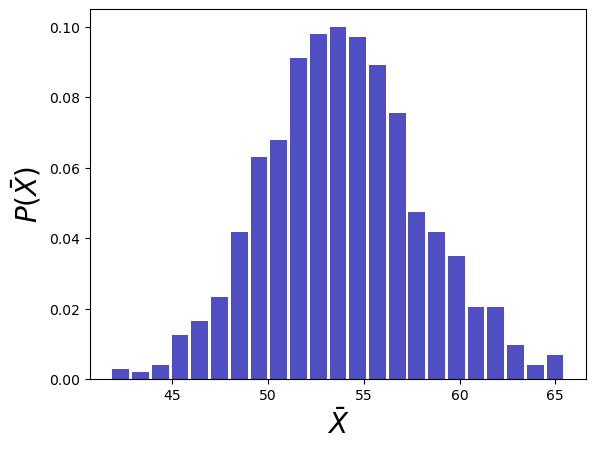

Media das amostras: 53.8855 Media da população: 54.0


In [ ]:
#plt.figure(figsize=(8,6))
plt.hist(x=vx, bins='auto',color='#0504aa', alpha=0.7, rwidth=0.85, density = True)
plt.xlabel(r'$\bar{X}$', fontsize=20)
plt.ylabel(r'$P(\bar{X})$', fontsize=20)
plt.show(True)
print("Media das amostras:", np.mean(vx), "Media da população:", E)

**Exemplo:** O tempo que um cliente gasta em um banco,  em minutos, segue o modelo exponencial com parâmetro igual a 1/5. Observando-se uma amostra aleatória de 50 pessoas que passaram pelo banco, qual será a probabilidade de que tais amostras em média não ultrapassem 6 minutos?

In [ ]:
# Calculo do valor teorico
x = 6
E = 5
V = 25
n = 50
z = (x-E)/(np.sqrt(V/n))
print('z = ', z)
p = st.norm.cdf(z)
print('Valor teórico:')
display(Math(r'P(\bar{X} <'+str(x) +')=' +str(p)))

z =  1.414213562373095
Valor teórico:


<IPython.core.display.Math object>

In [ ]:
import numpy as np

lbd = 1/5 # taxa
theta = 1/lbd # esperanca
n = 50 # tamanho da amostra
t = 6
ns = 1000 # numero de simulacoes
sucesso = 0
for s in range(0,ns):
    x = np.random.exponential(theta, n)
    m = np.mean(x) # media amostral
    if(m < t):
        sucesso = sucesso + 1
print('Prob. = ', sucesso/ns)

Prob. =  0.907


**Exemplo:** Suponha que $p=$70\% dos alunos de uma escola são mulheres. Coletamos uma amostra de 100 pessoas e calculamos a proporção de mulheres na amostra. Qual é a probabilidade de que tal proporção difira de $p$ em menos de 0,05?


A probabilidade pedida:
$$
\begin{aligned}
P(| \bar{X} - p| < 0,05) & = P(-0,05 < \bar{X} - p < 0,05)\\
& = P\left( \frac{-0,05}{\sqrt{\frac{p(1-p)}{n}}}< \frac{\bar{X} - p}{\sqrt{\frac{p(1-p)}{n}}} < \frac{0,05}{\sqrt{\frac{p(1-p)}{n}}}\right)\\
&= P\left( \frac{-0,05}{\sqrt{\frac{0,7(1-0,7)}{100}}}< Z < \frac{0,05}{\sqrt{\frac{0,7(1-0,7)}{100}}}\right)\\
& = P(-1,09 <Z<1,09) \\
&= P(Z<1,09)-P(Z<-1,09)\\
& = 0,725.
\end{aligned}
$$
Portanto,  dentre 1000 amostras de tamanho 100 que coletarmos, aproximadamente 720 delas diferirão da proporção $p$ em menos de 0,05.

In [ ]:
from IPython.display import display, Math, Latex
import scipy.stats as st
import numpy as np
np.random.seed(42)
p = 0.7
n = 100
V = p*(1-p)
px = 0.05
z1 = (-px)/np.sqrt(V/n)
z2 = (px)/np.sqrt(V/n)
print('z1 = ', z1, 'z2 = ',z2)
p = st.norm.cdf(z2)-st.norm.cdf(z1)
print('Valor teórico:')
display(Math(r'P(|\bar{X}-p| <'+str(px) +')=' +str(p)))

z1 =  -1.0910894511799618 z2 =  1.0910894511799618
Valor teórico:


<IPython.core.display.Math object>

Simulando:

In [ ]:
from IPython.display import display, Math
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

p = 0.7 # probabilidade de sucesso
n = 100 # tamanho da amostra
X = [0,1] # valores de X
P = [1-p,p] # distribuição de probabilidade
px = 0.05 # diferença entre p e a fração de sucessos
ns = 1000 # número de simulações
freq = 0
for s in range(0,ns):
    x = np.random.choice(X, n, p=P)
    if(np.abs(np.mean(x) - p) < px):
        freq = freq + 1
freq = freq/ns
print('Valor simulado:')
display(Math(r'P(|\bar{X}=p| <'+str(px) +')=' +str(freq)))

Valor simulado:


<IPython.core.display.Math object>

**Exemplo:**  Seja a variável aleatória com distribuição de probabilidade: P(X=10)=0,4; P(X=50)=0,2; P(X=100)=0,4. Uma amostra com 100 observações é sorteada. Qual é a probabilidade de que a média amostral ser menor do que 40?

Temos:
$$
E[X] = \mu =  10\times 0,4 + 50\times 0,2 + 100\times 0,4 = 54.
$$
De maneira similar:
$$
V(X) = \sigma^2 = 10^2\times 0,4 + 50^2\times 0,2 + 100^2\times 0,4 - 54^2 = 1624.
$$
Vamos calcular $P(\bar{X} < 40)$:
$$
\begin{aligned}
P(\bar{X} < 40) &= P\left(\frac{\bar{X} - \mu}{\sigma / \sqrt{n}} < \frac{40 - \mu}{\sigma /\sqrt{n}} \right)\\
& = P(\left(Z < \frac{40 - 54}{\sqrt{1624/100}} \right)\\
&= P(Z < 1,48) = 0,93.
\end{aligned}
$$

Simulando:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# valores da variável aleatória
X = [10,50,100]
# probabilidades associadas
P = [0.4,0.2,0.4]
E = 0 # esperança
E2 = 0 # segundo momento
for i in range(0, len(X)):
    E = E + X[i]*P[i]
    E2 = E2 + (X[i]**2)*P[i]
V = E2-E**2
print("Esperança:", E, "Variância:",V)

# Calculo do valor teórico
x = 60
z = (x-E)/(np.sqrt(V/n))
print('z = ', z)
p = st.norm.cdf(z)
print('Valor teórico:')
display(Math(r'P(\bar{X} <'+str(x) +')=' +str(p)))

# simulação
n = 100 # número de amostras
ns = 1000 # número de simulações
vx = [] # armazena a média amostral
for s in range(0,ns):
    A = np.random.choice(X, n, p=P)
    vx.append(np.mean(A))
nmenor = 0
for i in range(0, len(vx)):
    if(vx[i] < x):
        nmenor = nmenor + 1
nmenor = nmenor/len(vx)
print('Valor simulado:')
display(Math(r'P(\bar{X} <'+str(x) +')=' +str(nmenor)))

Esperança: 54.0 Variância: 1624.0
z =  1.4888750009563954
Valor teórico:


<IPython.core.display.Math object>

Valor simulado:


<IPython.core.display.Math object>